# Quick-look for KUL-TN-20 simulations

This notebook can be used to have a quicklook at the that product for the simulations described in PLATO-PL-TN-0020. Note that the `LightCurve` class used to analyse the data assumes a identical structure of the data products as they are delivered on the KU Leuven FTP server.

### Setup notebook

In [132]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [133]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Load light curves for one star

In [119]:
# Load all data for a single star
sims = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/"
idir = f"{sims}/P5/lightcurve_without_maskupdate/000000051"
lcs = LightCurve(idir, mode="multi")
# To fetch a specific light curve, use instead:
# lc = LightCurve(f"{idir}/000000083/000000083_Ncam1.1_Q23.ftr")

In [120]:
# Unzip all compressed files for the same star
lcs.unpack()

In [121]:
# Fetch all feather filenames
filenames = lcs.files("ftr")
filenames

['/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000051/000000051_Ncam1.1_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000051/000000051_Ncam1.2_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000051/000000051_Ncam1.3_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000051/000000051_Ncam1.4_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000051/000000051_Ncam1.5_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000051/000000051_Ncam1.6_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_without_maskupdate/000000051/000000051_Ncam2.1_Q23.ftr',
 '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020//P5/lightcurve_w

## Single N-CAM and Single Quarter

In [122]:
# Fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,index,time,flux,xc,yc,flux_cor
0,0,171072012.5,72396.490194,2.688480,3.370228,1.181096
1,1,171072037.5,72887.316076,2.693581,3.371441,1.181003
2,2,171072062.5,71748.871842,2.690515,3.365319,1.180911
3,3,171072087.5,71791.056664,2.697462,3.365823,1.180727
4,4,171072112.5,71918.150381,2.696883,3.367416,1.180914


In [123]:
# Get target star information
star = lc.star_info(lcs.files("cat")[0])
star

,Pmag,rOA,ncon,rcon,dmag,SPR
0,11.83,12.913712,2,1.431232,1.17,0.422578


In [124]:
# Get noise-less light curve
lc.varsource()

,time,sum
0,171072025.0,-9912.321072
1,171072050.0,-9911.637144
2,171072075.0,-9910.944096
3,171072100.0,-9910.241928
4,171072125.0,-9909.539760
...,...,...
622074,186623875.0,3508.769341
622075,186623900.0,3502.419655
622076,186623925.0,3496.060767
622077,186623950.0,3489.701920


<IPython.core.display.Javascript object>


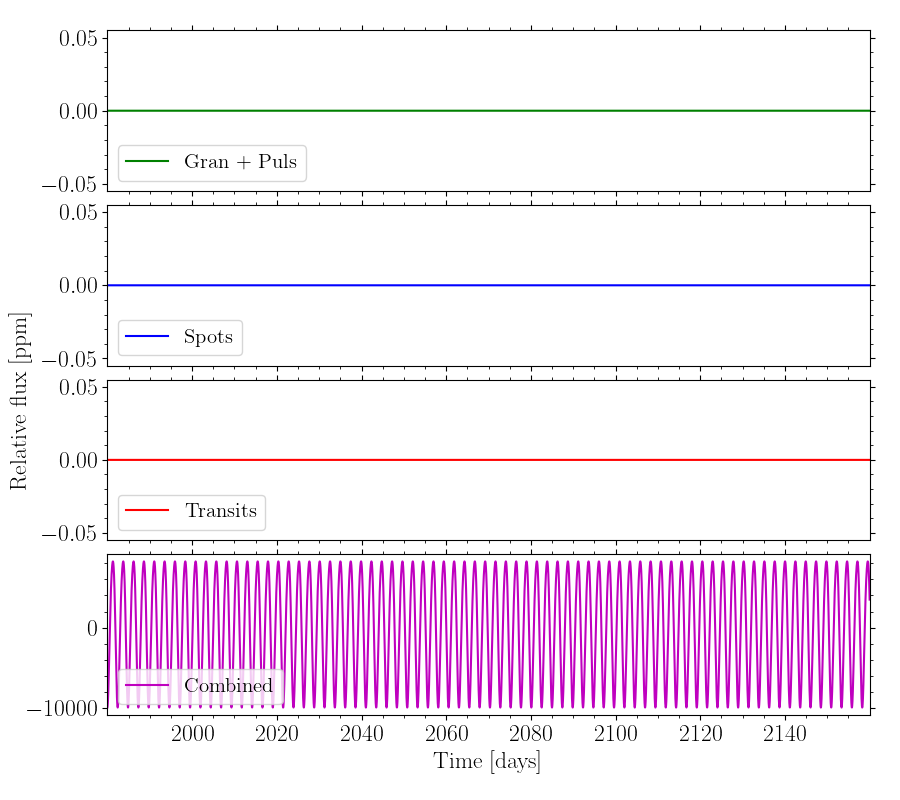

In [125]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

<IPython.core.display.Javascript object>


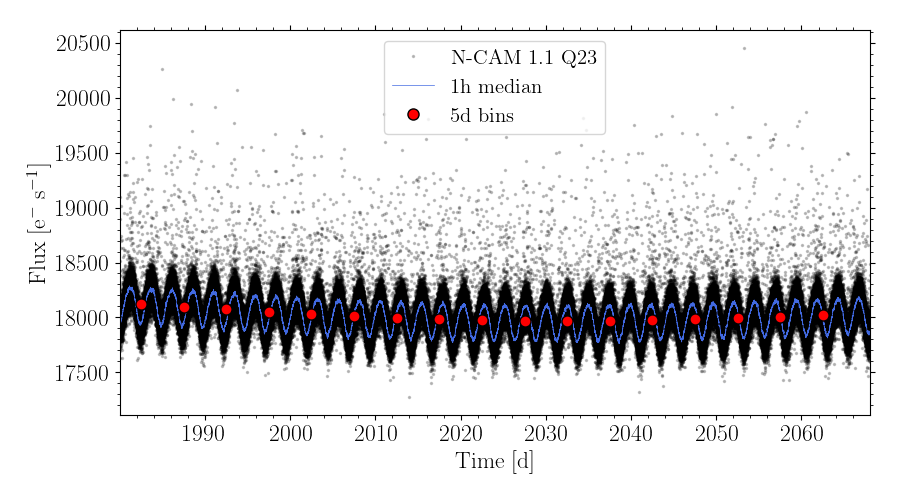

In [126]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=1);

<IPython.core.display.Javascript object>


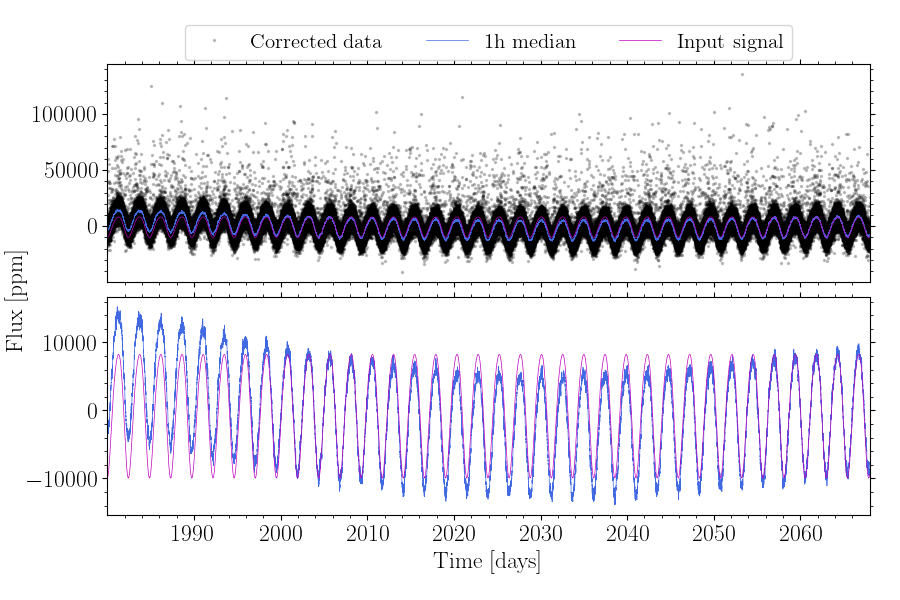

In [127]:
# Plot a quick O-C comparison plot 
fig, ax = lc.plot_oc();

<IPython.core.display.Javascript object>


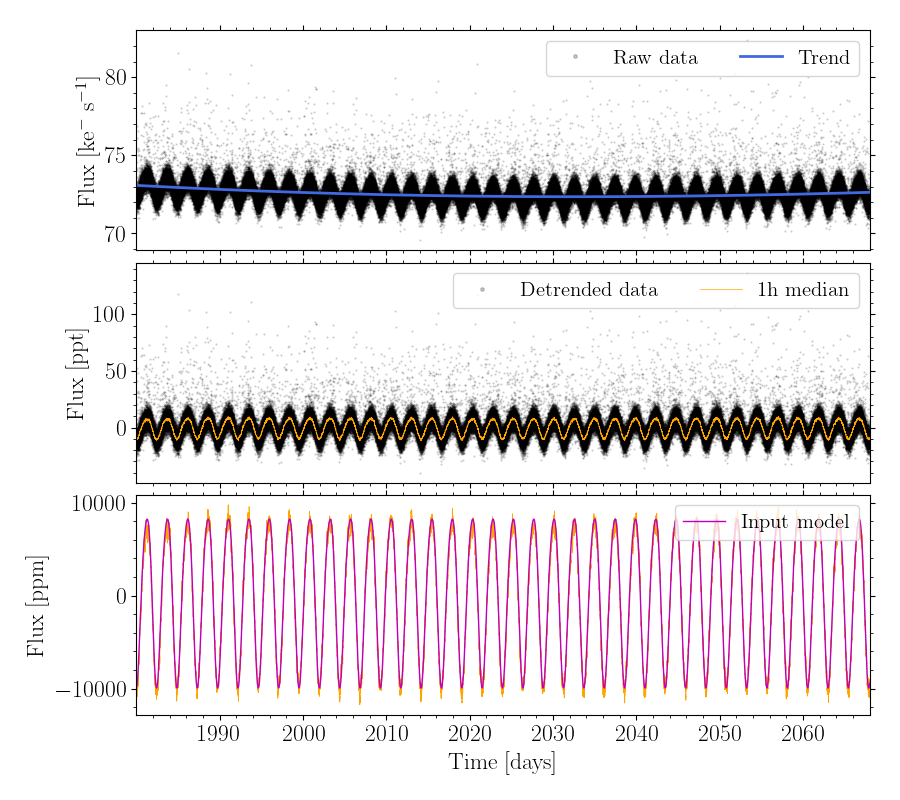

In [128]:
# Detrend light curve
lc.detrend(model='poly', degree=3, plot=True);

In [129]:
df = lc.detrend()
df

,index,time,flux,xc,yc,flux_cor,flux_trend,flux_detrend
0,0,171072012.5,72396.490194,2.688480,3.370228,1.181096,73060.635219,-9090.326449
1,1,171072037.5,72887.316076,2.693581,3.371441,1.181003,73060.627469,-2372.158564
2,2,171072062.5,71748.871842,2.690515,3.365319,1.180911,73060.619720,-17954.239679
3,3,171072087.5,71791.056664,2.697462,3.365823,1.180727,73060.611970,-17376.740652
4,4,171072112.5,71918.150381,2.696883,3.367416,1.180914,73060.604221,-15637.070782
...,...,...,...,...,...,...,...,...
304123,304123,178675087.5,71862.852603,2.650233,3.516912,1.248981,72643.953214,-10752.451880
304124,304124,178675112.5,72091.504674,2.646549,3.515415,1.249522,72643.958224,-7604.948343
304125,304125,178675137.5,74044.902776,2.642324,3.551283,1.249436,72643.963233,19285.009799
304126,304126,178675162.5,70832.405153,2.648603,3.515465,1.249764,72643.968243,-24937.556875


## All N-CAMs and Single Qaurter

<IPython.core.display.Javascript object>


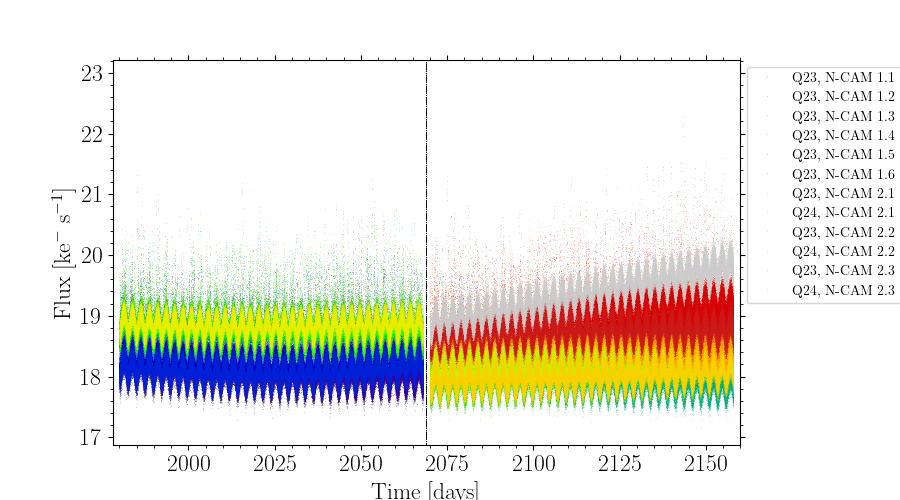

In [130]:
# Plot all light curves but for specific group, camera, or quarter
lcs.plot_multi(group=False, camera=False, quarter=False, flux_unit="e/s");

## Remember to remove unpacked files again!

In [131]:
lcs.remove()